# 01 — Exploração dos dados da ANA

Confere a série diária padronizada (`data/processed/cotas_diarias.parquet`) antes de construir qualquer modelo:

1. Cobertura por ano e por fonte
2. As fontes se comparam: régua da ANA × porto × sensor
3. A série completa de Manaus com os limiares do estudo
4. Mínimos anuais e a frequência de cruzamento dos limiares (taxa base)
5. Lacunas durante a vazante
6. Manaus × Manacapuru

Para regenerar os dados: `uv run python -m supplyrisk.download` e depois `uv run python -m supplyrisk.serie`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from supplyrisk import serie

MANAUS, MANACAPURU = 14990000, 14100000
LIMIARES_CM = {"17,70 m (ONE)": 1770, "15,0 m (seca extrema)": 1500}

cotas = pd.read_parquet(serie.PROCESSED_DIR / "cotas_diarias.parquet")
cotas["ano"] = cotas["data"].dt.year
manaus = cotas[cotas["estacao"] == MANAUS].set_index("data")
manacapuru = cotas[cotas["estacao"] == MANACAPURU].set_index("data")
cotas.groupby("estacao")["data"].agg(["min", "max", "count"])

,min,max,count
estacao,,,
14100000,1972-01-01,2026-10-06,20003
14990000,1902-09-15,2026-10-06,45313


## 1. Cobertura por ano e por fonte

In [2]:
cobertura = (
    cotas.dropna(subset=["cota_cm"])
    .groupby(["estacao", "ano", "fonte"]).size()
    .unstack("fonte", fill_value=0)
)
cobertura.loc[MANAUS].tail(20)

fonte,convencional_bruta,convencional_consistida,porto_manaus,telemetria
ano,,,,
2007,0,365,0,0
2008,0,366,0,0
2009,0,365,0,0
2010,0,365,0,0
2011,0,365,0,0
2012,0,366,0,0
2013,0,365,0,0
2014,0,358,7,0
2015,0,0,365,0


In [3]:
cobertura.loc[MANACAPURU].tail(20)

fonte,convencional_bruta,convencional_consistida,porto_manaus,telemetria
ano,,,,
2007,0,365,0,0
2008,0,366,0,0
2009,0,365,0,0
2010,0,365,0,0
2011,0,365,0,0
2012,0,366,0,0
2013,0,365,0,0
2014,0,365,0,0
2015,0,365,0,0


## 2. As fontes se comparam

Se duas fontes medem a mesma régua, a diferença nos dias de sobreposição deve ficar perto de zero.

### Régua da ANA × sensor da ANA

In [4]:
for codigo in (MANAUS, MANACAPURU):
    dif = serie.sobreposicao(codigo)["diferenca_cm"]
    print(codigo, f"{len(dif)} dias em comum")
    if not dif.empty:
        print(dif.describe(percentiles=[.05, .5, .95]).round(1).to_string(), "\n")

14990000 492 dias em comum
count    492.0
mean      -3.9
std        5.0
min      -24.2
5%       -11.7
50%       -2.7
95%        1.1
max        6.6 

14100000 5666 dias em comum
count    5666.0
mean       10.6
std        82.8
min      -186.0
5%         -6.3
50%         0.0
95%        10.4
max       819.3 



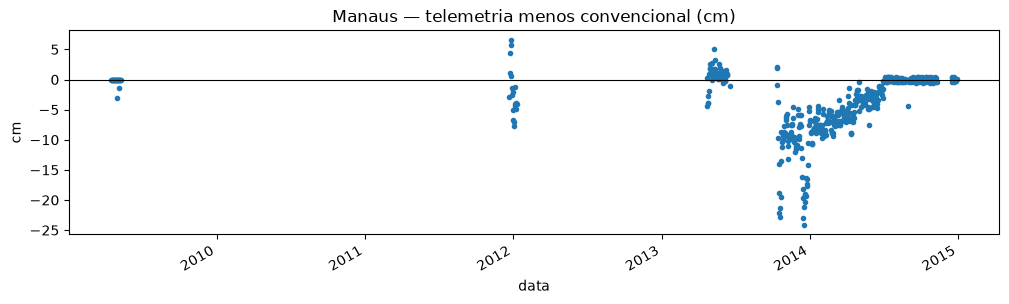

In [5]:
dif = serie.sobreposicao(MANAUS)
fig, ax = plt.subplots(figsize=(12, 3))
dif["diferenca_cm"].plot(ax=ax, marker=".", lw=0)
ax.axhline(0, color="k", lw=.8)
ax.set_title("Manaus — telemetria menos convencional (cm)")
ax.set_ylabel("cm");

### Porto de Manaus × ANA

Se o porto for a mesma régua da ANA, as duas devem coincidir em 2000–2014. O sensor da ANA é comparado com o porto em todo o período.

In [6]:
porto_dia = pd.read_parquet(serie.RAW_DIR / "porto_manaus.parquet").set_index("data")["cota_cm"]
regua_ana = serie.diaria_convencional(pd.read_parquet(serie.RAW_DIR / "ana_convencional_14990000.parquet"))["cota_cm"]
sensor_ana = serie.diaria_telemetria(pd.read_parquet(serie.RAW_DIR / "ana_telemetria_14990000.parquet"))["cota_cm"]

comparacoes = {}
for nome, outra in (("régua ANA − porto", regua_ana), ("sensor ANA − porto", sensor_ana)):
    juntas = pd.concat([porto_dia, outra], axis=1, keys=["porto", "ana"], sort=True).dropna()
    comparacoes[nome] = juntas["ana"] - juntas["porto"]
    dif = comparacoes[nome]
    print(f"{nome}: {len(dif)} dias, mediana {dif.median():.1f} cm, "
          f"até 2 cm em {(dif.abs() <= 2).mean():.0%} dos dias, p1 {dif.quantile(.01):.1f}, p99 {dif.quantile(.99):.1f}")

régua ANA − porto: 5469 dias, mediana 0.0 cm, até 2 cm em 90% dos dias, p1 -6.0, p99 4.0
sensor ANA − porto: 4593 dias, mediana -2.0 cm, até 2 cm em 29% dos dias, p1 -42.2, p99 16.1


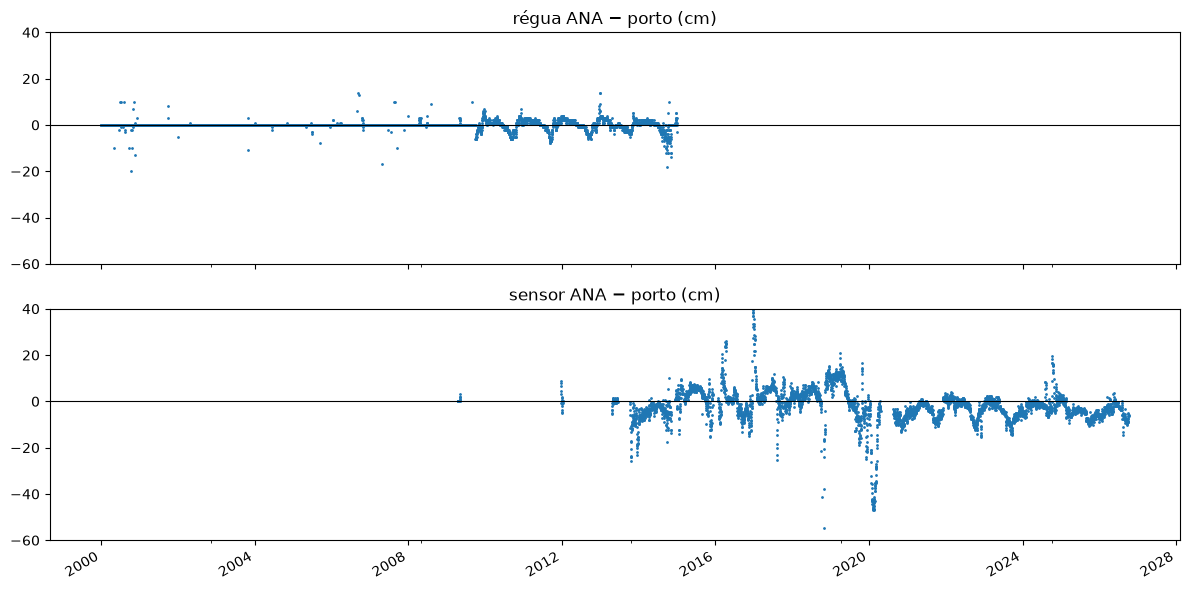

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, (nome, dif) in zip(axes, comparacoes.items()):
    dif.plot(ax=ax, lw=0, marker=".", ms=2)
    ax.axhline(0, color="k", lw=.8)
    ax.set_ylim(-60, 40)
    ax.set_title(nome + " (cm)")
plt.tight_layout();

## 3. Série completa de Manaus

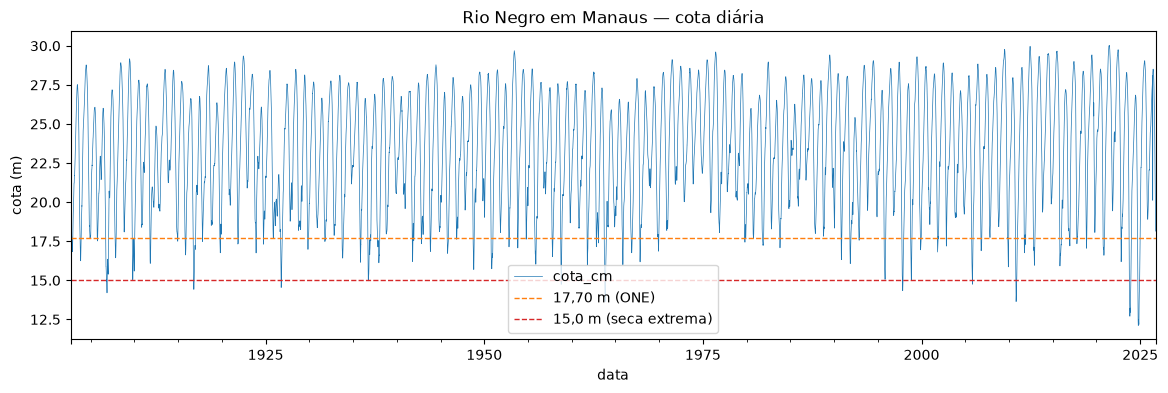

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
(manaus["cota_cm"] / 100).plot(ax=ax, lw=.5)
for nome, cm in LIMIARES_CM.items():
    ax.axhline(cm / 100, ls="--", lw=1, label=nome, color="tab:red" if cm == 1500 else "tab:orange")
ax.set_ylabel("cota (m)")
ax.set_title("Rio Negro em Manaus — cota diária")
ax.legend();

## 4. Mínimos anuais e taxa base

Quantos anos cruzaram cada limiar? Isso define o quanto os eventos são raros e, portanto, o que um bom Brier score significa. O ano corrente ainda não terminou a vazante e fica de fora.

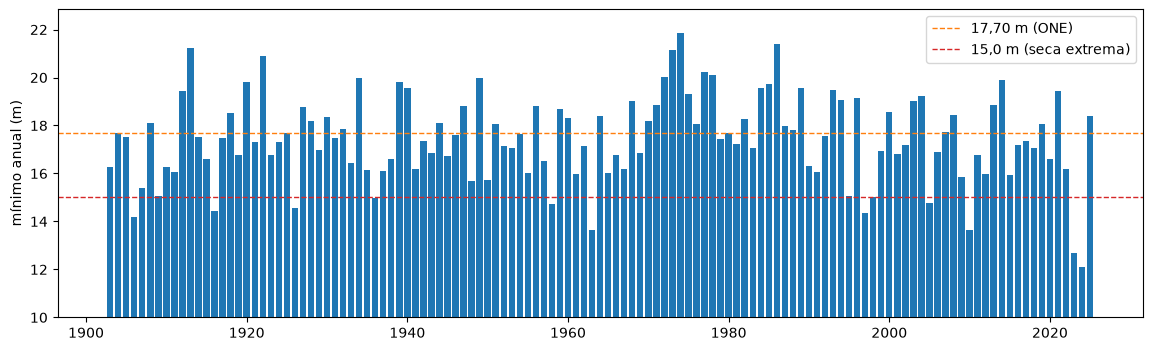

In [9]:
ano_corrente = pd.Timestamp.today().year
minimos = manaus[manaus["ano"] < ano_corrente].groupby("ano")["cota_cm"].agg(["min", "idxmin", "count"])
minimos = minimos[minimos["count"] >= 300]  # só anos quase completos
minimos["min_m"] = minimos["min"] / 100

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(minimos.index, minimos["min_m"], width=.8)
for nome, cm in LIMIARES_CM.items():
    ax.axhline(cm / 100, ls="--", lw=1, label=nome, color="tab:red" if cm == 1500 else "tab:orange")
ax.set_ylim(10, minimos["min_m"].max() + 1)
ax.set_ylabel("mínimo anual (m)")
ax.legend();

In [10]:
for nome, cm in LIMIARES_CM.items():
    cruzou = minimos["min"] <= cm
    print(f"{nome}: {cruzou.sum()} de {len(minimos)} anos ({cruzou.mean():.0%})")

minimos["decada"] = minimos.index // 10 * 10
minimos.groupby("decada").agg(
    anos=("min", "size"),
    abaixo_17_70=("min", lambda s: (s <= 1770).sum()),
    abaixo_15=("min", lambda s: (s <= 1500).sum()),
    menor_minimo_m=("min_m", "min"),
)

17,70 m (ONE): 72 de 123 anos (59%)
15,0 m (seca extrema): 11 de 123 anos (9%)


,anos,abaixo_17_70,abaixo_15,menor_minimo_m
decada,,,,
1900,7,6,1,14.20
1910,10,7,1,14.42
1920,10,6,1,14.54
1930,10,6,1,14.97
1940,10,6,0,15.69
1950,10,7,1,14.74
1960,10,7,1,13.64
1970,10,1,0,17.44
1980,10,3,0,17.08


In [11]:
# As vazantes mais severas
minimos.nsmallest(10, "min")[["min_m", "idxmin"]]

,min_m,idxmin
ano,,
2024,12.11,2024-10-09
2023,12.70,2023-10-26
1963,13.64,1963-10-30
2010,13.64,2010-10-24
1906,14.20,1906-11-13
1997,14.34,1997-11-04
1916,14.42,1916-10-17
1926,14.54,1926-10-12
1958,14.74,1958-10-18


## 5. Lacunas durante a vazante

As previsões são diárias entre 1º de julho e o mínimo anual. Dias sem dado nesse período reduzem o que cada modelo pode ver.

In [12]:
vazante = manaus[manaus.index.month.isin([7, 8, 9, 10, 11, 12])]
lacunas = vazante["cota_cm"].isna().groupby(vazante["ano"]).sum()
lacunas[lacunas > 0]

Series([], Name: cota_cm, dtype: int64)

## 6. Manaus × Manacapuru

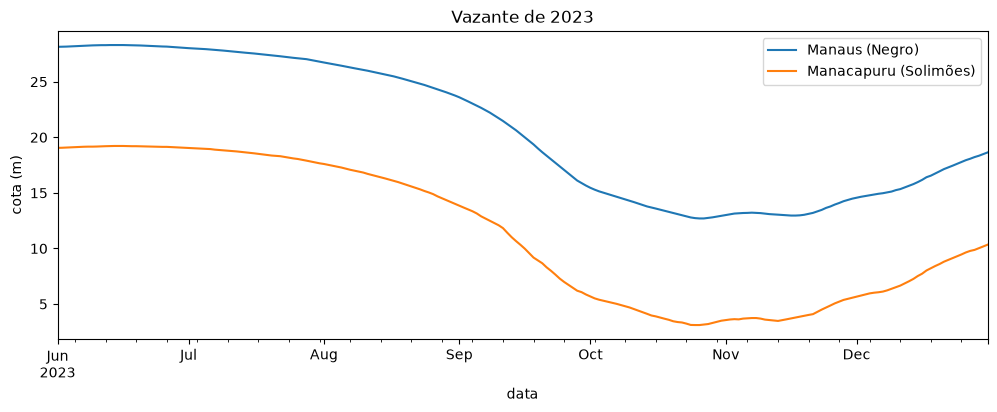

In [13]:
ano = 2023
fig, ax = plt.subplots(figsize=(12, 4))
for df, nome in ((manaus, "Manaus (Negro)"), (manacapuru, "Manacapuru (Solimões)")):
    trecho = df.loc[f"{ano}-06-01":f"{ano}-12-31", "cota_cm"] / 100
    trecho.plot(ax=ax, label=nome)
ax.set_ylabel("cota (m)")
ax.set_title(f"Vazante de {ano}")
ax.legend();